# PINN pro 1D lineární elastostatiku

Cílem je pomocí **Physics-Informed Neural Network (PINN)** aproximovat posunutí jednodimenzionální elastické tyče.

## Formulace úlohy

Uvažujeme tyč na intervalu

$$
\Omega=(0,1)
$$

s konstantním Youngovým modulem $E>0$. Předepsané přesné řešení je

$$
u(x)=a\sin(2\pi x), \qquad a>0.
$$

Deformace a napětí jsou

$$
\varepsilon(x)=u'(x), \qquad \sigma(x)=E\,u'(x).
$$

Rovnice rovnováhy má tvar

$$
\sigma'(x)+b(x)=0,
$$

tedy

$$
\frac{\mathrm d}{\mathrm dx}\left(Eu'(x)\right)+b(x)=0.
$$

Pro zvolené přesné řešení vychází objemová síla

$$
b(x)=4\pi^2Ea\sin(2\pi x).
$$

Okrajové podmínky jsou

$$
u(0)=0, \qquad u(1)=0.
$$

Aby se tyř lokálně nepřeklopila nebo nestlačila do jednoho bodu, požadujeme $1+u'(x)>0$, a proto volíme

$$
0<a<\frac{1}{2\pi}.
$$


## 1. Import knihoven

In [27]:
import copy
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 2. Nastavení parametrů

Zde se nastavuje materiál, amplituda, počty bodů a délka trénování.

- `USE_DATA=True`: hybridní PINN s několika známými hodnotami řešení.
- `USE_DATA=False`: čistá PINN založená pouze na PDE a okrajových podmínkách.
- `N_PDE_TRAIN`: kolokační body použité ve fyzikální loss.
- `N_PDE_TEST`: nezávislé body pro závěrečnou kontrolu PDE.
- `N_DATA_TRAIN`: známé hodnoty použité při trénování.
- `N_DATA_TEST`: známé hodnoty použité pouze při testování.

Celkem proběhne 2000 epoch. Prvních 2000 používá Adam a posledních 100 L-BFGS.

In [28]:
USE_DATA = True  # False -> cista PINN bez dat

L = 1.0
E_CONST = 1.0
AMPLITUDE = 0.01

N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 100
N_DATA_TRAIN = 10
N_DATA_VALIDATION = 5
N_DATA_TEST = 5

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
torch.manual_seed(42)


## 3. Přesné řešení a fyzikální veličiny


In [29]:
def exact_solution(x):
    """Analyticke reseni u(x) = a*sin(2*pi*x)."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def young_modulus(x):
    """Konstantni Younguv modul E."""
    return E_CONST * torch.ones_like(x)


def body_force(x):
    """b(x) odvozena z rovnovahy (E*u')' + b = 0."""
    return (
        4.0
        * torch.pi**2
        * E_CONST
        * AMPLITUDE
        * torch.sin(2.0 * torch.pi * x)
    )


## 4. Neuronová síť

In [30]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        return self.net(x)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Fyzikální trénovací, validační a testovací body

Trénovací body vstupují do optimalizace. Pevných 1000 validačních bodů vybírá nejlepší epochu a testovací body se použijí až po obnovení nejlepšího modelu.


In [31]:
x_pde_train = torch.linspace(0.0, L, N_PDE_TRAIN).view(-1, 1)
x_pde_train.requires_grad_(True)

validation_generator = torch.Generator().manual_seed(122)
x_pde_validation = L * torch.rand(N_PDE_VALIDATION, 1, generator=validation_generator)
x_pde_validation, _ = torch.sort(x_pde_validation, dim=0)

test_generator = torch.Generator().manual_seed(123)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)
x_pde_test.requires_grad_(True)


tensor([[0.0114],
        [0.0126],
        [0.0275],
        [0.0353],
        [0.0390],
        [0.0740],
        [0.0756],
        [0.0772],
        [0.0950],
        [0.0969],
        [0.1025],
        [0.1166],
        [0.1186],
        [0.1366],
        [0.1459],
        [0.1479],
        [0.1634],
        [0.1841],
        [0.1908],
        [0.1955],
        [0.1966],
        [0.2251],
        [0.2318],
        [0.2517],
        [0.2745],
        [0.2775],
        [0.2961],
        [0.3009],
        [0.3033],
        [0.3111],
        [0.3153],
        [0.3164],
        [0.3565],
        [0.3821],
        [0.3834],
        [0.3950],
        [0.4017],
        [0.4066],
        [0.4220],
        [0.4340],
        [0.4354],
        [0.4451],
        [0.4527],
        [0.4545],
        [0.4606],
        [0.4702],
        [0.5112],
        [0.5159],
        [0.5166],
        [0.5183],
        [0.5201],
        [0.5299],
        [0.5331],
        [0.5786],
        [0.5789],
        [0

## 6. Volitelná supervizovaná data

Při `USE_DATA=True` jsou trénovací, validační a testovací hodnoty vzájemně oddělené. Validační hodnoty pouze vybírají checkpoint.


In [32]:
if USE_DATA:
    x_data_train = torch.linspace(0.0, L, N_DATA_TRAIN + 2)[1:-1].view(-1, 1)
    u_data_train = exact_solution(x_data_train)
    data_validation_generator = torch.Generator().manual_seed(455)
    x_data_validation = L * torch.rand(N_DATA_VALIDATION, 1, generator=data_validation_generator)
    x_data_validation, _ = torch.sort(x_data_validation, dim=0)
    u_data_validation = exact_solution(x_data_validation)
    data_test_generator = torch.Generator().manual_seed(456)
    x_data_test = L * torch.rand(N_DATA_TEST, 1, generator=data_test_generator)
    x_data_test, _ = torch.sort(x_data_test, dim=0)
    u_data_test = exact_solution(x_data_test)
    print(f'Supervizovana data: {N_DATA_TRAIN} trenovacich, {N_DATA_VALIDATION} validacnich, {N_DATA_TEST} testovacich bodu.')


Supervizovana data: 10 trenovacich, 5 validacnich, 5 testovacich bodu.


## 7. Ztrátová funkce, validace a trénování

Trénovací loss obsahuje PDE, okrajové podmínky a případná trénovací data. Validační loss obsahuje reziduum na nezávislých kolokačních bodech a při `USE_DATA=True` také chybu na validačních datech:

$$
\mathcal L_{\mathrm{val}}=\mathcal L_{\mathrm{val,PDE}}+\mathcal L_{\mathrm{val,data}}.
$$

Validační body nevstupují do zpětné propagace.


In [33]:
loss_history, pde_loss_history, bc_loss_history, data_loss_history = [], [], [], []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
snimky = {}
x_plot = torch.linspace(0.0, L, 200).view(-1, 1)
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float('inf')
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    u = model(x)
    du = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    sigma = young_modulus(x) * du
    dsigma = torch.autograd.grad(sigma, x, grad_outputs=torch.ones_like(sigma), create_graph=training)[0]
    return dsigma + body_force(x)


def compute_losses():
    loss_pde = torch.mean(pde_residual(x_pde_train, training=True)**2)
    loss_bc = torch.mean(model(torch.tensor([[0.0]]))**2) + torch.mean(model(torch.tensor([[L]]))**2)
    loss_data = torch.mean((model(x_data_train) - u_data_train)**2) if USE_DATA else torch.tensor(0.0)
    loss = loss_pde + loss_bc + loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    validation_residual = pde_residual(x_pde_validation, training=False).detach()
    loss_validation_pde = torch.mean(validation_residual**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(x_data_validation) - u_data_validation)**2) if USE_DATA else torch.tensor(0.0)
    return loss_validation_pde + loss_validation_data, loss_validation_pde, loss_validation_data


def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_data_loss, best_epoch, best_model_state
    model.eval()
    validation, validation_pde, validation_data = compute_validation_losses()
    validation_value, validation_pde_value, validation_data_value = validation.item(), validation_pde.item(), validation_data.item()
    validation_loss_history.append(validation_value)
    validation_pde_loss_history.append(validation_pde_value)
    validation_data_loss_history.append(validation_data_value)
    if best_model_state is None or validation_value < best_validation_loss:
        best_validation_loss = validation_value
        best_validation_pde_loss = validation_pde_value
        best_validation_data_loss = validation_data_value
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    model.train()
    return validation_value


for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss.backward()
    optimizer_adam.step()
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 100 == 0:
        print(f'Adam | epocha {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | BC={loss_bc.item():.6e} | validation={validation_value:.6e}')
        with torch.no_grad():
            snimky[epoch] = model(x_plot).detach().numpy().copy()

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn='strong_wolfe')
for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_losses()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f'L-BFGS | epocha {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | BC={loss_bc.item():.6e} | validation={validation_value:.6e}')

model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    snimky['best'] = model(x_plot).detach().numpy().copy()
print(f'Nejlepsi epocha: {best_epoch}')
print(f'Nejmensi kombinovana validacni loss: {best_validation_loss:.6e}')
print(f'Validacni PDE MSE: {best_validation_pde_loss:.6e}')
print(f'Validacni datova MSE: {best_validation_data_loss:.6e}')


Adam | epocha     0 | loss=1.855346e-01 | PDE=1.297490e-01 | BC=4.587958e-02 | validation=1.394629e-01
Adam | epocha   100 | loss=3.727619e-02 | PDE=3.426018e-02 | BC=2.758152e-03 | validation=3.350006e-02
Adam | epocha   200 | loss=2.101019e-02 | PDE=2.076144e-02 | BC=2.331703e-04 | validation=2.007543e-02
Adam | epocha   300 | loss=1.096044e-02 | PDE=1.095024e-02 | BC=6.518402e-06 | validation=1.173674e-02
Adam | epocha   400 | loss=5.694822e-03 | PDE=5.636721e-03 | BC=4.910673e-05 | validation=6.771251e-03
Adam | epocha   500 | loss=4.436768e-03 | PDE=4.417708e-03 | BC=1.553349e-05 | validation=5.241337e-03
Adam | epocha   600 | loss=3.744455e-03 | PDE=3.729202e-03 | BC=1.243859e-05 | validation=4.420896e-03
Adam | epocha   700 | loss=3.065578e-03 | PDE=3.047149e-03 | BC=1.541071e-05 | validation=3.650926e-03
Adam | epocha   800 | loss=2.438127e-03 | PDE=2.418044e-03 | BC=1.704244e-05 | validation=2.938761e-03
Adam | epocha   900 | loss=1.899207e-03 | PDE=1.880362e-03 | BC=1.611050e

## 8. Vyhodnocení na kolokačních testovacích bodech

Závěrečné vyhodnocení obsahuje pouze metriky vypočtené na nezávislých bodech `x_pde_test`, které nebyly použity při trénování:

- **$R^2$ skóre** predikovaného posunutí,
- **relativní $L^2$ chyba** posunutí,
- **MSE PDE rezidua**.

Koeficient determinace je

$$
R^2
=
1-
\frac{\sum_i\left(u_\theta(x_i)-u(x_i)\right)^2}
{\sum_i\left(u(x_i)-\bar{u}\right)^2}.
$$

Relativní chyba je

$$
\frac{\lVert u_\theta-u\rVert_2}{\lVert u\rVert_2}.
$$

In [34]:
model.eval()

u_pde_test_prediction = model(x_pde_test)

du_pde_test = torch.autograd.grad(
    outputs=u_pde_test_prediction,
    inputs=x_pde_test,
    grad_outputs=torch.ones_like(u_pde_test_prediction),
    create_graph=True,
)[0]

sigma_pde_test = young_modulus(x_pde_test) * du_pde_test

dsigma_pde_test = torch.autograd.grad(
    outputs=sigma_pde_test,
    inputs=x_pde_test,
    grad_outputs=torch.ones_like(sigma_pde_test),
    create_graph=True,
)[0]

residual_pde_test = dsigma_pde_test + body_force(x_pde_test)
pde_test_mse = torch.mean(residual_pde_test**2).detach().item()


# R2 a relativni L2 chyba na stejnych kolokacnich testovacich bodech.
with torch.no_grad():
    u_test_prediction = model(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (
        torch.linalg.vector_norm(u_test_prediction - u_test_exact)
        / torch.linalg.vector_norm(u_test_exact)
    ).item()


metrics = {
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "best_validation_PDE_MSE": best_validation_pde_loss,
    "best_validation_data_MSE": best_validation_data_loss,
    "R2_collocation_test": r2_test,
    "relative_L2_collocation_test": relative_l2_test,
    "PDE_test_MSE": pde_test_mse,
}


print("=" * 60)
print("TESTOVACI VYSLEDKY PINN")
print("=" * 60)
print(f"R2 na kolokacnich testovacich bodech: {r2_test:.8f}")
print(f"Relativni L2 chyba na techto bodech:   {relative_l2_test:.6e}")
print(f"MSE PDE rezidua na techto bodech:      {pde_test_mse:.6e}")
print("=" * 60)

metrics


TESTOVACI VYSLEDKY PINN
R2 na kolokacnich testovacich bodech: 1.00000000
Relativni L2 chyba na techto bodech:   1.495098e-04
MSE PDE rezidua na techto bodech:      4.258957e-08


{'best_epoch': 1913,
 'best_validation_loss': 4.9646875055486817e-08,
 'best_validation_PDE_MSE': 4.964579503052846e-08,
 'best_validation_data_MSE': 1.0804029112326807e-12,
 'R2_collocation_test': 1.0,
 'relative_L2_collocation_test': 0.0001495098404120654,
 'PDE_test_MSE': 4.2589572757378846e-08}

In [35]:
x_plot = torch.linspace(0.0, L, 400).view(-1, 1)

# Ulozeni modelu z posledni epochy.
model.eval()
with torch.no_grad():
    snimky['last'] = model(x_plot).detach().numpy().copy()

# Obnoveni modelu z nejlepsi validacni epochy.
model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    snimky['best'] = model(x_plot).detach().numpy().copy()

print(f'Nejlepsi epocha: {best_epoch}')
print(f'Nejmensi validacni loss: {best_validation_loss:.6e}')


def plot_data_split():
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4.5))
    if ncols == 1:
        axes = [axes]

    axes[0].scatter(x_pde_train.detach().numpy(), 2 * np.ones((len(x_pde_train), 1)), color='tab:blue', s=25, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_validation.numpy(), np.ones((len(x_pde_validation), 1)), color='tab:green', marker='s', s=25, label=f'PDE validation ({len(x_pde_validation)})')
    axes[0].scatter(x_pde_test.detach().numpy(), np.zeros((len(x_pde_test), 1)), color='tab:orange', marker='x', s=25, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1, 2], labels=['test', 'validation', 'train'])
    axes[0].set(xlabel='x', title='Collocation points', ylim=(-0.5, 2.5))
    axes[0].legend()
    axes[0].grid(axis='x')

    if USE_DATA:
        x_dense = torch.linspace(0.0, L, 400).view(-1, 1)
        axes[1].plot(x_dense.numpy(), exact_solution(x_dense).numpy(), 'k--', label='Exact solution')
        axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(), color='tab:blue', s=45, label=f'Data train ({len(x_data_train)})', zorder=3)
        axes[1].scatter(x_data_validation.numpy(), u_data_validation.numpy(), color='tab:green', marker='s', s=45, label=f'Data validation ({len(x_data_validation)})', zorder=3)
        axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=45, label=f'Data test ({len(x_data_test)})', zorder=3)
        axes[1].set(xlabel='x', ylabel='u(x)', title='Supervised data')
        axes[1].legend()
        axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_points_and_data.pdf', bbox_inches='tight')
    plt.show()


def plot_solution():
    u_exact = exact_solution(x_plot)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.numpy(), u_exact.numpy(), 'k--', linewidth=2, label='Exact')
    ax.plot(x_plot.numpy(), snimky['best'], linewidth=2, label=f'Best epoch ({best_epoch})')
    ax.plot(x_plot.numpy(), snimky['last'], ':', linewidth=2, label='Last epoch')
    ax.set(xlabel='x', ylabel='u(x)', title='PINN displacement')
    ax.legend()
    ax.grid()

    fig.tight_layout()
    plt.savefig('pinn_solution.pdf', bbox_inches='tight')
    plt.show()


def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='total')
    axes[0].plot(pde_loss_history, label='PDE')
    axes[0].plot(bc_loss_history, label='boundary conditions')
    if USE_DATA:
        axes[0].plot(data_loss_history, label='supervised data')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(validation_loss_history, label='combined validation')
    axes[1].plot(validation_pde_loss_history, label='PDE')
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, label='data')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[1].set_yscale('log')
    axes[1].set(xlabel='epoch', ylabel='loss', title='Validation losses')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_losses.pdf', bbox_inches='tight')
    plt.show()


def plot_relative_absolute_error():
    with torch.no_grad():
        u_prediction = model(x_plot)
        u_exact = exact_solution(x_plot)
        relative_absolute_error = torch.abs(u_prediction - u_exact) / torch.max(torch.abs(u_exact))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(x_plot.numpy(), relative_absolute_error.numpy())
    ax.set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute displacement error')
    ax.grid()

    fig.tight_layout()
    plt.savefig('pinn_relative_absolute_error.pdf', bbox_inches='tight')
    plt.show()



Nejlepsi epocha: 1913
Nejmensi validacni loss: 4.964688e-08


## 9. Vizualizační funkce


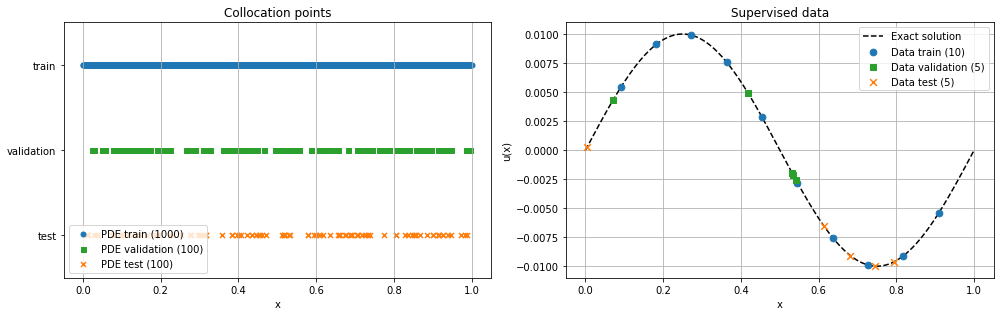

In [36]:
plot_data_split()


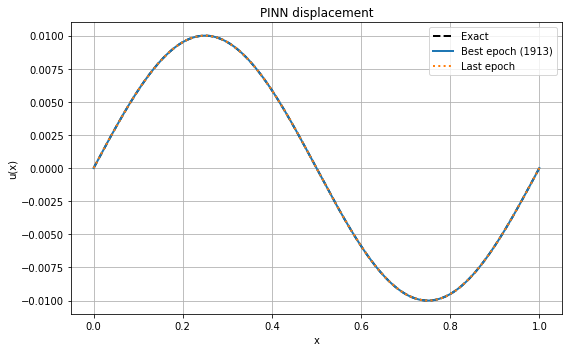

In [37]:
plot_solution()


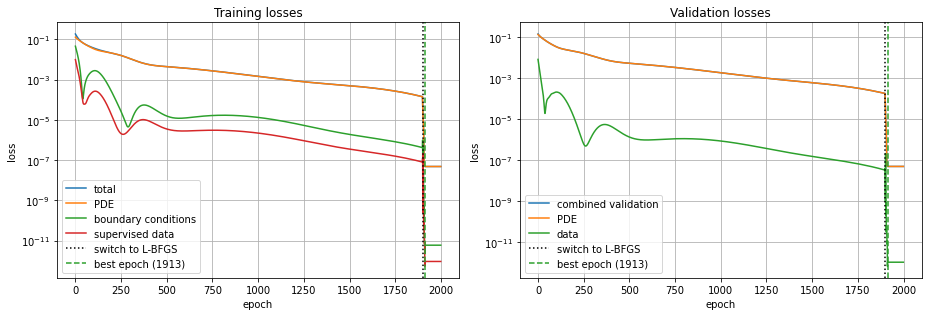

In [38]:
plot_loss()


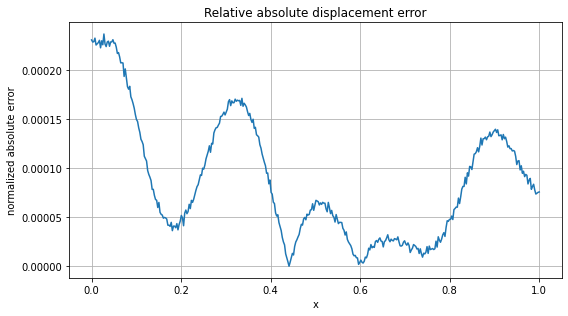

In [39]:
plot_relative_absolute_error()